### **Notebook #4**

# Group 2: Luca Milani, Marta Laskowska, Monika Kaczorowska
## EDA - Stock Price Data

### Libraries

In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
import requests
import bs4 as bs
import yfinance as yf
import datetime
from scipy.stats import norm
from collections import Counter


from ipywidgets import interact, IntSlider, Checkbox
from functools import lru_cache
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option('display.max_colwidth', None)

### Dataset Preparation

In [65]:
def load_excel_sheets_except_request_table(
    file_path: str,
    date_col: str = "Name",
    skip_sheets=("REQUEST_TABLE",)
) -> pd.DataFrame:
    
    """
    Read all sheets from an Excel file (except specific ones)
    and merge them on a shared key column (e.g. 'Name').
    """

    # Read all sheets into a dict: {sheet_name: DataFrame}
    book = pd.read_excel(file_path, sheet_name=None, engine="openpyxl")

    frames = []
    for sheet_name, df in book.items():
        if sheet_name in skip_sheets:
            continue
        if df.empty:
            continue

        # Ensure the date column exists; skip if missing
        if date_col not in df.columns:
            continue

        # Clean & standardize date
        df = df.copy()
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        frames.append(df)

    if not frames:
        return pd.DataFrame()  # nothing usable

    merged_df = frames[0]

    # Iteratively merge with the rest on 'Name'
    for other_df in frames[1:]:
        merged_df = pd.merge(
            merged_df,
            other_df,
            on=date_col,
            how="outer",  # use 'outer' to keep all names across sheets
            suffixes=("", "_dup")
        )

    return merged_df

In [66]:
banks_ri = load_excel_sheets_except_request_table("banks_data_bocconi/banks_ri.xlsm")
display(banks_ri.head())

,Name,AAREAL BANK - TOT RETURN IND,COMDIRECT BANK - TOT RETURN IND,COMMERZBANK - TOT RETURN IND,DT.PFANDBRIEFBANK - TOT RETURN IND,PROCREDIT HOLDING - TOT RETURN IND,UMWELTBANK - TOT RETURN IND,ALLIANZ - TOT RETURN IND,DEUTSCHE BANK - TOT RETURN IND,BANQUE NATIONALE DE BELGIQUE - TOT RETURN IND,KBC ANCORA - TOT RETURN IND,KBC GROUP - TOT RETURN IND,BANK OF CYPRUS HOLDING - TOT RETURN IND,HELLENIC BANK - TOT RETURN IND,LHV GROUP - TOT RETURN IND,BBV.ARGENTARIA - TOT RETURN IND,BANCO DE SABADELL - TOT RETURN IND,BANCO SANTANDER - TOT RETURN IND,BANKIA - TOT RETURN IND,BANKINTER 'R' - TOT RETURN IND,CAIXABANK - TOT RETURN IND,LIBERBANK - TOT RETURN IND,UNICAJA BANCO - TOT RETURN IND,AKTIA BANK A - TOT RETURN IND,NORDEA BANK - TOT RETURN IND,BNP PARIBAS - TOT RETURN IND,CRCAM ILLE-VIL.CCI - TOT RETURN IND,CRCAM NORD CCI - TOT RETURN IND,CREDIT AGRICOLE - TOT RETURN IND,CREDIT AGRICOLE BRIE PICARDIE - TOT RETURN IND,CREDIT AGR.ILE DE FRANCE - TOT RETURN IND,CREDIT FONCIER DE MONACO - TOT RETURN IND,NATIXIS - TOT RETURN IND,SOCIETE GENERALE - TOT RETURN IND,BANQUE DE SAVOIE DEAD - 01/04/10 - TOT RETURN IND,CREDIT AGRICOLE - TOT RETURN IND.1,MERSEN (EX LCL) - TOT RETURN IND,ALPHA BANK - TOT RETURN IND,ATTICA BANK - TOT RETURN IND,BANK OF GREECE - TOT RETURN IND,BANK OF PIRAEUS - TOT RETURN IND,EUROBANK HOLDINGS - TOT RETURN IND,NATIONAL BK.OF GREECE - TOT RETURN IND,AIB GROUP - TOT RETURN IND,BANK OF IRELAND GROUP - TOT RETURN IND,PERMANENT TSB GHG. - TOT RETURN IND,BANCA GENERALI - TOT RETURN IND,BANCA MONTE DEI PASCHI - TOT RETURN IND,BCA.PICCOLO CDT.VALTELL - TOT RETURN IND,BANCA PPO.DI SONDRIO - TOT RETURN IND,BANCO BPM - TOT RETURN IND,BNC.DI DESIO E DELB. - TOT RETURN IND,BPER BANCA - TOT RETURN IND,CREDITO EMILIANO - TOT RETURN IND,FINECOBANK SPA - TOT RETURN IND,ILLIMITY BANK - TOT RETURN IND,INTESA SANPAOLO - TOT RETURN IND,UNICREDIT - TOT RETURN IND,UNIONE DI BANCHE ITALIAN - TOT RETURN IND,MEDIOBANCA BC.FIN - TOT RETURN IND,SIAULIU BANKAS - TOT RETURN IND,BANK OF VALLETTA - TOT RETURN IND,FIMBANK - TOT RETURN IND,HSBC BANK MALTA - TOT RETURN IND,LOMBARD BANK - TOT RETURN IND,ABN AMRO BANK - TOT RETURN IND,ING GROEP - TOT RETURN IND,NIBC HOLDING - TOT RETURN IND,VAN LANSCHOT KEMPEN - TOT RETURN IND,ASR NEDERLAND - TOT RETURN IND,AEGON - TOT RETURN IND,DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - TOT RETURN IND,BANK FUR TIROL UND VBG. - TOT RETURN IND,BAWAG GROUP - TOT RETURN IND,BKS BANK - TOT RETURN IND,ERSTE GROUP BANK - TOT RETURN IND,OBERBANK - TOT RETURN IND,OBERBANK PREF. - TOT RETURN IND,RAIFFEISEN BANK INTL. - TOT RETURN IND,BANCO COMR.PORTUGUES 'R' - TOT RETURN IND,NOVA LJUBLJANSKA BANK DD NPV - TOT RETURN IND,OTP BANKA SLOVENSKO - TOT RETURN IND,OTP BANKA SLOVENSKO2 - TOT RETURN IND,OTP BANKA SLOVENSKO3 - TOT RETURN IND,TATRA BANKA - TOT RETURN IND,TATRA BANKA 2 - TOT RETURN IND,VSEOBECNA UVEROVA BANKA - TOT RETURN IND,BANK OF AMERICA - TOT RETURN IND,TRUIST FINANCIAL - TOT RETURN IND,BOK FINL. - TOT RETURN IND,CIT GROUP - TOT RETURN IND,CITIZENS FINANCIAL GROUP - TOT RETURN IND,COMERICA - TOT RETURN IND,COMMERCE BCSH. - TOT RETURN IND,CREDICORP - TOT RETURN IND,CULLEN FO.BANKERS - TOT RETURN IND,DISCOVER FINANCIAL SVS. - TOT RETURN IND,EAST WEST BANCORP - TOT RETURN IND,FIFTH THIRD BANCORP - TOT RETURN IND,FIRST CTZN.BCSH.A - TOT RETURN IND,FIRST FINL.BKSH. - TOT RETURN IND,FIRST HORIZON NATIONAL - TOT RETURN IND,FIRST REPUBLIC BANK - TOT RETURN IND,FNB - TOT RETURN IND,HUNTINGTON BCSH. - TOT RETURN IND,IBERIABANK - TOT RETURN IND,KEYCORP - TOT RETURN IND,M&T BANK - TOT RETURN IND,NEW YORK COMMUNITY BANCORP - TOT RETURN IND,PACWEST BANCORP - TOT RETURN IND,PEOPLES UNITED FINANCIAL - TOT RETURN IND,PINNACLE FINANCIAL PTNS. - TOT RETURN IND,PNC FINL.SVS.GP. - TOT RETURN IND,POPULAR - TOT RETURN IND,PROSPERITY BCSH. - TOT RETURN IND,REGIONS FINL.NEW - TOT RETURN IND,SIGNATURE BANK - TOT RETURN IND,STERLING BANCORP - TOT RETURN IND,SVB FINANCIAL GROUP - TOT RETURN IND,SYNOVUS FINANCIAL - TOT RETURN IND,TCF FINANCIAL - TO

In [67]:
bank_ri_scand = load_excel_sheets_except_request_table("banks_data_bocconi/scandinavian_banks_ri.xlsm")
display(bank_ri_scand.head())

,Name,BANQUE CANTON.DE GENEVE - TOT RETURN IND,BANQUE CANTONALE VAUDOISE - TOT RETURN IND,BASELLANDSCHAFTLICH E KANTONALBANK - TOT RETURN IND,BERNER KANTONALBANK - TOT RETURN IND,CEMBRA MONEY BANK N ORD - TOT RETURN IND,EFG INTERNATIONAL N - TOT RETURN IND,GRAUB KB 'P' - TOT RETURN IND,LIECHTENSTEINISCHE LANDESBANK - TOT RETURN IND,LUZERNER KANTONALBANK - TOT RETURN IND,SCHWEIZERISCHE NAT.BK. - TOT RETURN IND,ST GALLER KANTONALBANK - TOT RETURN IND,THURGAUER KANTONALBANK - TOT RETURN IND,VALIANT 'R' - TOT RETURN IND,VONTOBEL HOLDING - TOT RETURN IND,VP BANK - TOT RETURN IND,WALLISER KANTONALBANK - TOT RETURN IND,ZUGER KANTONALBANK - TOT RETURN IND,DNB - TOT RETURN IND,MYBANK - TOT RETURN IND,NORWEGIAN FINANS HOLDING - TOT RETURN IND,SPAREBANK 1 OSTLANDET - TOT RETURN IND,SPAREBANK 1 SMN ORDS - TOT RETURN IND,SPAREBANK 1 SR-BANK - TOT RETURN IND,AVANZA BANK HOLDING - TOT RETURN IND,SKANDINAVISKA ENSKILDA BANKEN A - TOT RETURN IND,SVENSKA HANDELSBANKEN A - TOT RETURN IND,SWEDBANK A - TOT RETURN IND
0,2008-01-01,112.58,588.28,821.00,211.61,NaN,115.53,823.96,436.23,549.11,504.42,386.38,NaN,545.87,330.42,1055.58,253.42,417.08,1755.09,NaN,NaN,NaN,1038.09,1345.10,2221.74,4647.10,7051.14,718.48
1,2008-01-02,112.58,588.28,821.09,211.61,NaN,115.53,824.05,436.23,549.11,504.42,386.38,NaN,545.87,330.42,1055.72,253.42,417.08,1776.23,NaN,NaN,NaN,1041.68,1340.02,2242.24,4604.98,6983.02,714.55
2,2008-01-03,111.39,577.42,822.03,211.61,NaN,112.74,829.13,429.43,544.92,504.42,387.55,NaN,545.87,319.86,1021.02,253.42,413.35,1738.17,NaN,NaN,NaN,1048.86,1329.87,2229.94,4647.10,6914.89,716.52
3,2008-01-04,111.39,565.97,822.12,212.61,NaN,103.85,834.21,429.65,542.30,504.42,376.30,NaN,545.25,313.52,989.14,251.86,414.59,1721.26,NaN,NaN,NaN,1052.46,1340.02,2127.46,4534.79,6795.66,696.89
4,2008-01-07,112.58,541.31,822.21,211.12,NaN,92.81,829.30,418.69,541.78,504.42,369.70,NaN,546.49,300.25,990.23,253.68,418.33,1721.26,NaN,NaN,NaN,1041.68,1314.64,2045.48,4506.71,6846.76,692.96


In [68]:
banks_pi = load_excel_sheets_except_request_table("banks_data_bocconi/banks_pi.xlsm")
display(banks_pi.head())

,Name,AAREAL BANK - PRICE INDEX,COMDIRECT BANK - PRICE INDEX,COMMERZBANK - PRICE INDEX,DT.PFANDBRIEFBANK - PRICE INDEX,PROCREDIT HOLDING - PRICE INDEX,UMWELTBANK - PRICE INDEX,ALLIANZ - PRICE INDEX,DEUTSCHE BANK - PRICE INDEX,BANQUE NATIONALE DE BELGIQUE - PRICE INDEX,KBC ANCORA - PRICE INDEX,KBC GROUP - PRICE INDEX,BANK OF CYPRUS HOLDING - PRICE INDEX,HELLENIC BANK - PRICE INDEX,LHV GROUP - PRICE INDEX,BBV.ARGENTARIA - PRICE INDEX,BANCO DE SABADELL - PRICE INDEX,BANCO SANTANDER - PRICE INDEX,BANKIA - PRICE INDEX,BANKINTER 'R' - PRICE INDEX,CAIXABANK - PRICE INDEX,LIBERBANK - PRICE INDEX,UNICAJA BANCO - PRICE INDEX,AKTIA BANK A - PRICE INDEX,NORDEA BANK - PRICE INDEX,BNP PARIBAS - PRICE INDEX,CRCAM ILLE-VIL.CCI - PRICE INDEX,CRCAM NORD CCI - PRICE INDEX,CREDIT AGRICOLE - PRICE INDEX,CREDIT AGRICOLE BRIE PICARDIE - PRICE INDEX,CREDIT AGR.ILE DE FRANCE - PRICE INDEX,CREDIT FONCIER DE MONACO - PRICE INDEX,NATIXIS - PRICE INDEX,SOCIETE GENERALE - PRICE INDEX,BANQUE DE SAVOIE DEAD - 01/04/10 - PRICE INDEX,CREDIT AGRICOLE - PRICE INDEX.1,MERSEN (EX LCL) - PRICE INDEX,ALPHA BANK - PRICE INDEX,ATTICA BANK - PRICE INDEX,BANK OF GREECE - PRICE INDEX,BANK OF PIRAEUS - PRICE INDEX,EUROBANK HOLDINGS - PRICE INDEX,NATIONAL BK.OF GREECE - PRICE INDEX,AIB GROUP - PRICE INDEX,BANK OF IRELAND GROUP - PRICE INDEX,PERMANENT TSB GHG. - PRICE INDEX,BANCA GENERALI - PRICE INDEX,BANCA MONTE DEI PASCHI - PRICE INDEX,BCA.PICCOLO CDT.VALTELL - PRICE INDEX,BANCA PPO.DI SONDRIO - PRICE INDEX,BANCO BPM - PRICE INDEX,BNC.DI DESIO E DELB. - PRICE INDEX,BPER BANCA - PRICE INDEX,CREDITO EMILIANO - PRICE INDEX,FINECOBANK SPA - PRICE INDEX,ILLIMITY BANK - PRICE INDEX,INTESA SANPAOLO - PRICE INDEX,UNICREDIT - PRICE INDEX,UNIONE DI BANCHE ITALIAN - PRICE INDEX,MEDIOBANCA BC.FIN - PRICE INDEX,SIAULIU BANKAS - PRICE INDEX,BANK OF VALLETTA - PRICE INDEX,FIMBANK - PRICE INDEX,HSBC BANK MALTA - PRICE INDEX,LOMBARD BANK - PRICE INDEX,ABN AMRO BANK - PRICE INDEX,ING GROEP - PRICE INDEX,NIBC HOLDING - PRICE INDEX,VAN LANSCHOT KEMPEN - PRICE INDEX,ASR NEDERLAND - PRICE INDEX,AEGON - PRICE INDEX,DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - PRICE INDEX,BANK FUR TIROL UND VBG. - PRICE INDEX,BAWAG GROUP - PRICE INDEX,BKS BANK - PRICE INDEX,ERSTE GROUP BANK - PRICE INDEX,OBERBANK - PRICE INDEX,OBERBANK PREF. - PRICE INDEX,RAIFFEISEN BANK INTL. - PRICE INDEX,ERSTE GROUP BANK - PRICE INDEX.1,RAIFFEISEN BANK INTL. - PRICE INDEX.1,VOLKSBANK VBG.PARTN. - PRICE INDEX,BANCO COMR.PORTUGUES 'R' - PRICE INDEX,NOVA LJUBLJANSKA BANK DD NPV - PRICE INDEX,OTP BANKA SLOVENSKO - PRICE INDEX,OTP BANKA SLOVENSKO2 - PRICE INDEX,OTP BANKA SLOVENSKO3 - PRICE INDEX,TATRA BANKA - PRICE INDEX,TATRA BANKA 2 - PRICE INDEX,VSEOBECNA UVEROVA BANKA - PRICE INDEX,BANK OF AMERICA - PRICE INDEX,TRUIST FINANCIAL - PRICE INDEX,BOK FINL. - PRICE INDEX,CIT GROUP - PRICE INDEX,CITIZENS FINANCIAL GROUP - PRICE INDEX,COMERICA - PRICE INDEX,COMMERCE BCSH. - PRICE INDEX,CREDICORP - PRICE INDEX,CULLEN FO.BANKERS - PRICE INDEX,DISCOVER FINANCIAL SVS. - PRICE INDEX,EAST WEST BANCORP - PRICE INDEX,FIFTH THIRD BANCORP - PRICE INDEX,FIRST CTZN.BCSH.A - PRICE INDEX,FIRST FINL.BKSH. - PRICE INDEX,FIRST HORIZON NATIONAL - PRICE INDEX,FIRST REPUBLIC BANK - PRICE INDEX,FNB - PRICE INDEX,HUNTINGTON BCSH. - PRICE INDEX,IBERIABANK - PRICE INDEX,KEYCORP - PRICE INDEX,M&T BANK - PRICE INDEX,NEW YORK COMMUNITY BANCORP - PRICE INDEX,PACWEST BANCORP - PRICE INDEX,PEOPLES UNITED FINANCIAL - PRICE INDEX,PINNACLE FINANCIAL PTNS. - PRICE INDEX,PNC FINL.SVS.GP. - PRICE INDEX,POPULAR - PRICE INDEX,PROSPERITY BCSH. - PRICE INDEX,REGIONS FINL.NEW - PRICE INDEX,SIGNATURE BANK - PRICE INDEX,STERLING BANCORP - PRICE INDEX,SVB FINANCIAL GROUP - PRICE INDEX,SYNOVUS FINANCIAL - PRICE INDEX,TCF FINANCIAL - PRICE INDEX,TFS FINANCIAL - PRICE INDEX,TRISTATE CAPITAL HOLDINGS DS - PRICE INDEX,UNITED BANKSHARES - PRICE INDEX,US BANCORP - PRICE INDEX,WEBSTER FINANCIAL - PRICE INDEX,WELLS FARGO & CO - PRICE INDEX,WESTERN ALL.BANCORP. - PRICE INDEX,ZIONS BANCORP. 

In [69]:
bank_pi_scand = load_excel_sheets_except_request_table("banks_data_bocconi/scandinavian_banks_pi.xlsm")
display(bank_pi_scand.head())

,Name,BANQUE CANTON.DE GENEVE - PRICE INDEX,BANQUE CANTONALE VAUDOISE - PRICE INDEX,BASELLANDSCHAFTLICH E KANTONALBANK - PRICE INDEX,BERNER KANTONALBANK - PRICE INDEX,CEMBRA MONEY BANK N ORD - PRICE INDEX,EFG INTERNATIONAL N - PRICE INDEX,GRAUB KB 'P' - PRICE INDEX,LIECHTENSTEINISCHE LANDESBANK - PRICE INDEX,LUZERNER KANTONALBANK - PRICE INDEX,SCHWEIZERISCHE NAT.BK. - PRICE INDEX,ST GALLER KANTONALBANK - PRICE INDEX,THURGAUER KANTONALBANK - PRICE INDEX,VALIANT 'R' - PRICE INDEX,VONTOBEL HOLDING - PRICE INDEX,VP BANK - PRICE INDEX,WALLISER KANTONALBANK - PRICE INDEX,ZUGER KANTONALBANK - PRICE INDEX,DNB - PRICE INDEX,MYBANK - PRICE INDEX,NORWEGIAN FINANS HOLDING - PRICE INDEX,SPAREBANK 1 OSTLANDET - PRICE INDEX,SPAREBANK 1 SMN ORDS - PRICE INDEX,SPAREBANK 1 SR-BANK - PRICE INDEX,AVANZA BANK HOLDING - PRICE INDEX,SKANDINAVISKA ENSKILDA BANKEN A - PRICE INDEX,SVENSKA HANDELSBANKEN A - PRICE INDEX,SWEDBANK A - PRICE INDEX
0,2008-01-01,85.4,229.4,404.9,186.4,NaN,114.9,431.8,274.5,268.3,243.5,327.2,NaN,473.0,190.1,642.7,154.6,211.7,830.0,NaN,NaN,NaN,418.3,517.9,1265.4,1747.7,3844.0,450.0
1,2008-01-02,85.4,229.4,404.9,186.4,NaN,114.9,431.8,274.5,268.3,243.5,327.2,NaN,473.0,190.1,642.7,154.6,211.7,840.0,NaN,NaN,NaN,419.7,515.9,1277.1,1731.8,3806.9,447.5
2,2008-01-03,84.4,225.1,405.3,186.4,NaN,112.1,434.4,270.2,266.2,243.5,328.2,NaN,473.0,184.1,621.5,154.6,209.8,822.0,NaN,NaN,NaN,422.6,512.0,1270.1,1747.7,3769.8,448.8
3,2008-01-04,84.4,220.7,405.3,187.3,NaN,103.3,437.0,270.4,265.0,243.5,318.7,NaN,472.4,180.4,602.0,153.7,210.5,814.0,NaN,NaN,NaN,424.1,515.9,1211.7,1705.4,3704.8,436.5
4,2008-01-07,85.4,211.0,405.3,186.0,NaN,92.3,434.4,263.5,264.7,243.5,313.1,NaN,473.5,172.8,602.6,154.8,212.3,814.0,NaN,NaN,NaN,419.7,506.1,1165.0,1694.9,3732.6,434.0


In [70]:
fff_us = pd.read_excel('banks_data_bocconi/Europe_3_Factors_Daily.xlsx')
fff_eu = pd.read_excel('banks_data_bocconi/North_America_3_Factors_Daily.xlsx')

We'll be using the risk-free rate from Fama-French factors:

In [71]:
fff_us.head(2)

,date,Mkt-RF,SMB,HML,RF
0,07/02/1990,0.99,0.05,-0.53,0.03
1,07/03/1990,0.33,-0.12,-0.03,0.03


In [72]:
fff_eu.head(2)

,date,Mkt-RF,SMB,HML,RF
0,07/02/1990,0.30,-0.38,-0.12,0.03
1,07/03/1990,0.14,-0.08,-0.40,0.03


In [73]:
fff_us = fff_us.rename(columns={"RF": "RF_US", "Mkt-RF": "Mkt-RF_US", "SMB": "SMB_US", "HML": "HML_US", "Mkt": "Mkt_US"})
fff_eu = fff_eu.rename(columns={"RF": "RF_EU", "Mkt-RF": "Mkt-RF_EU", "SMB": "SMB_EU", "HML": "HML_EU", "Mkt": "Mkt_EU"})

Merging the datasets:

In [74]:
def clean_and_prepare_date(df, date_col="Name"):
    df = df.copy()

    if date_col not in df.columns:
        raise ValueError(f"Column '{date_col}' not found in dataframe.")

    # Clean and convert
    df[date_col] = (
        df[date_col]
        .astype(str)                      # ensure string type
        .str.strip()                      # remove whitespace
        .replace("", pd.NA)               # blank → NaN
    )

    # Convert to datetime safely
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
    return df

In [75]:
banks_ri = clean_and_prepare_date(banks_ri)
bank_ri_scand = clean_and_prepare_date(bank_ri_scand)
banks_pi = clean_and_prepare_date(banks_pi)
bank_pi_scand = clean_and_prepare_date(bank_pi_scand)

C:\Users\lasko\AppData\Local\Temp\ipykernel_12364\758106812.py:16: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
C:\Users\lasko\AppData\Local\Temp\ipykernel_12364\758106812.py:16: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
C:\Users\lasko\AppData\Local\Temp\ipykernel_12364\758106812.py:16: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a fu

In [76]:
merged_banks = (
    banks_ri
    .merge(bank_ri_scand, on="Name", how="outer", suffixes=("_ri", "_ri_scand"))
    .merge(banks_pi, on="Name", how="outer", suffixes=("", "_pi"))
    .merge(bank_pi_scand, on="Name", how="outer", suffixes=("", "_pi_scand"))
)

# Sort by date
merged_banks = merged_banks.sort_values("Name").reset_index(drop=True)

# Rename the date column for clarity (optional)
merged_banks.rename(columns={"Name": "date"}, inplace=True)

merged_banks.head()

,date,AAREAL BANK - TOT RETURN IND,COMDIRECT BANK - TOT RETURN IND,COMMERZBANK - TOT RETURN IND,DT.PFANDBRIEFBANK - TOT RETURN IND,PROCREDIT HOLDING - TOT RETURN IND,UMWELTBANK - TOT RETURN IND,ALLIANZ - TOT RETURN IND,DEUTSCHE BANK - TOT RETURN IND,BANQUE NATIONALE DE BELGIQUE - TOT RETURN IND,KBC ANCORA - TOT RETURN IND,KBC GROUP - TOT RETURN IND,BANK OF CYPRUS HOLDING - TOT RETURN IND,HELLENIC BANK - TOT RETURN IND,LHV GROUP - TOT RETURN IND,BBV.ARGENTARIA - TOT RETURN IND,BANCO DE SABADELL - TOT RETURN IND,BANCO SANTANDER - TOT RETURN IND,BANKIA - TOT RETURN IND,BANKINTER 'R' - TOT RETURN IND,CAIXABANK - TOT RETURN IND,LIBERBANK - TOT RETURN IND,UNICAJA BANCO - TOT RETURN IND,AKTIA BANK A - TOT RETURN IND,NORDEA BANK - TOT RETURN IND,BNP PARIBAS - TOT RETURN IND,CRCAM ILLE-VIL.CCI - TOT RETURN IND,CRCAM NORD CCI - TOT RETURN IND,CREDIT AGRICOLE - TOT RETURN IND,CREDIT AGRICOLE BRIE PICARDIE - TOT RETURN IND,CREDIT AGR.ILE DE FRANCE - TOT RETURN IND,CREDIT FONCIER DE MONACO - TOT RETURN IND,NATIXIS - TOT RETURN IND,SOCIETE GENERALE - TOT RETURN IND,BANQUE DE SAVOIE DEAD - 01/04/10 - TOT RETURN IND,CREDIT AGRICOLE - TOT RETURN IND.1,MERSEN (EX LCL) - TOT RETURN IND,ALPHA BANK - TOT RETURN IND,ATTICA BANK - TOT RETURN IND,BANK OF GREECE - TOT RETURN IND,BANK OF PIRAEUS - TOT RETURN IND,EUROBANK HOLDINGS - TOT RETURN IND,NATIONAL BK.OF GREECE - TOT RETURN IND,AIB GROUP - TOT RETURN IND,BANK OF IRELAND GROUP - TOT RETURN IND,PERMANENT TSB GHG. - TOT RETURN IND,BANCA GENERALI - TOT RETURN IND,BANCA MONTE DEI PASCHI - TOT RETURN IND,BCA.PICCOLO CDT.VALTELL - TOT RETURN IND,BANCA PPO.DI SONDRIO - TOT RETURN IND,BANCO BPM - TOT RETURN IND,BNC.DI DESIO E DELB. - TOT RETURN IND,BPER BANCA - TOT RETURN IND,CREDITO EMILIANO - TOT RETURN IND,FINECOBANK SPA - TOT RETURN IND,ILLIMITY BANK - TOT RETURN IND,INTESA SANPAOLO - TOT RETURN IND,UNICREDIT - TOT RETURN IND,UNIONE DI BANCHE ITALIAN - TOT RETURN IND,MEDIOBANCA BC.FIN - TOT RETURN IND,SIAULIU BANKAS - TOT RETURN IND,BANK OF VALLETTA - TOT RETURN IND,FIMBANK - TOT RETURN IND,HSBC BANK MALTA - TOT RETURN IND,LOMBARD BANK - TOT RETURN IND,ABN AMRO BANK - TOT RETURN IND,ING GROEP - TOT RETURN IND,NIBC HOLDING - TOT RETURN IND,VAN LANSCHOT KEMPEN - TOT RETURN IND,ASR NEDERLAND - TOT RETURN IND,AEGON - TOT RETURN IND,DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - TOT RETURN IND,BANK FUR TIROL UND VBG. - TOT RETURN IND,BAWAG GROUP - TOT RETURN IND,BKS BANK - TOT RETURN IND,ERSTE GROUP BANK - TOT RETURN IND,OBERBANK - TOT RETURN IND,OBERBANK PREF. - TOT RETURN IND,RAIFFEISEN BANK INTL. - TOT RETURN IND,BANCO COMR.PORTUGUES 'R' - TOT RETURN IND,NOVA LJUBLJANSKA BANK DD NPV - TOT RETURN IND,OTP BANKA SLOVENSKO - TOT RETURN IND,OTP BANKA SLOVENSKO2 - TOT RETURN IND,OTP BANKA SLOVENSKO3 - TOT RETURN IND,TATRA BANKA - TOT RETURN IND,TATRA BANKA 2 - TOT RETURN IND,VSEOBECNA UVEROVA BANKA - TOT RETURN IND,BANK OF AMERICA - TOT RETURN IND,TRUIST FINANCIAL - TOT RETURN IND,BOK FINL. - TOT RETURN IND,CIT GROUP - TOT RETURN IND,CITIZENS FINANCIAL GROUP - TOT RETURN IND,COMERICA - TOT RETURN IND,COMMERCE BCSH. - TOT RETURN IND,CREDICORP - TOT RETURN IND,CULLEN FO.BANKERS - TOT RETURN IND,DISCOVER FINANCIAL SVS. - TOT RETURN IND,EAST WEST BANCORP - TOT RETURN IND,FIFTH THIRD BANCORP - TOT RETURN IND,FIRST CTZN.BCSH.A - TOT RETURN IND,FIRST FINL.BKSH. - TOT RETURN IND,FIRST HORIZON NATIONAL - TOT RETURN IND,FIRST REPUBLIC BANK - TOT RETURN IND,FNB - TOT RETURN IND,HUNTINGTON BCSH. - TOT RETURN IND,IBERIABANK - TOT RETURN IND,KEYCORP - TOT RETURN IND,M&T BANK - TOT RETURN IND,NEW YORK COMMUNITY BANCORP - TOT RETURN IND,PACWEST BANCORP - TOT RETURN IND,PEOPLES UNITED FINANCIAL - TOT RETURN IND,PINNACLE FINANCIAL PTNS. - TOT RETURN IND,PNC FINL.SVS.GP. - TOT RETURN IND,POPULAR - TOT RETURN IND,PROSPERITY BCSH. - TOT RETURN IND,REGIONS FINL.NEW - TOT RETURN IND,SIGNATURE BANK - TOT RETURN IND,STERLING BANCORP - TOT RETURN IND,SVB FINANCIAL GROUP - TOT RETURN IND,SYNOVUS FINANCIAL - TOT RETURN IND,TCF FINANCIAL - TO

In [77]:
for df_name, df in [("fff_us", fff_us), ("fff_eu", fff_eu)]:
    if "date" not in df.columns:
        raise ValueError(f"{df_name} has no 'date' column")

fff_us["date"] = pd.to_datetime(fff_us["date"], errors="coerce", dayfirst=False)
fff_eu["date"] = pd.to_datetime(fff_eu["date"], errors="coerce", dayfirst=False)

In [78]:
merged_banks = (
    merged_banks
        .merge(fff_us, on="date", how="left")
        .merge(fff_eu, on="date", how="left")
)

display(merged_banks.head())

,date,AAREAL BANK - TOT RETURN IND,COMDIRECT BANK - TOT RETURN IND,COMMERZBANK - TOT RETURN IND,DT.PFANDBRIEFBANK - TOT RETURN IND,PROCREDIT HOLDING - TOT RETURN IND,UMWELTBANK - TOT RETURN IND,ALLIANZ - TOT RETURN IND,DEUTSCHE BANK - TOT RETURN IND,BANQUE NATIONALE DE BELGIQUE - TOT RETURN IND,KBC ANCORA - TOT RETURN IND,KBC GROUP - TOT RETURN IND,BANK OF CYPRUS HOLDING - TOT RETURN IND,HELLENIC BANK - TOT RETURN IND,LHV GROUP - TOT RETURN IND,BBV.ARGENTARIA - TOT RETURN IND,BANCO DE SABADELL - TOT RETURN IND,BANCO SANTANDER - TOT RETURN IND,BANKIA - TOT RETURN IND,BANKINTER 'R' - TOT RETURN IND,CAIXABANK - TOT RETURN IND,LIBERBANK - TOT RETURN IND,UNICAJA BANCO - TOT RETURN IND,AKTIA BANK A - TOT RETURN IND,NORDEA BANK - TOT RETURN IND,BNP PARIBAS - TOT RETURN IND,CRCAM ILLE-VIL.CCI - TOT RETURN IND,CRCAM NORD CCI - TOT RETURN IND,CREDIT AGRICOLE - TOT RETURN IND,CREDIT AGRICOLE BRIE PICARDIE - TOT RETURN IND,CREDIT AGR.ILE DE FRANCE - TOT RETURN IND,CREDIT FONCIER DE MONACO - TOT RETURN IND,NATIXIS - TOT RETURN IND,SOCIETE GENERALE - TOT RETURN IND,BANQUE DE SAVOIE DEAD - 01/04/10 - TOT RETURN IND,CREDIT AGRICOLE - TOT RETURN IND.1,MERSEN (EX LCL) - TOT RETURN IND,ALPHA BANK - TOT RETURN IND,ATTICA BANK - TOT RETURN IND,BANK OF GREECE - TOT RETURN IND,BANK OF PIRAEUS - TOT RETURN IND,EUROBANK HOLDINGS - TOT RETURN IND,NATIONAL BK.OF GREECE - TOT RETURN IND,AIB GROUP - TOT RETURN IND,BANK OF IRELAND GROUP - TOT RETURN IND,PERMANENT TSB GHG. - TOT RETURN IND,BANCA GENERALI - TOT RETURN IND,BANCA MONTE DEI PASCHI - TOT RETURN IND,BCA.PICCOLO CDT.VALTELL - TOT RETURN IND,BANCA PPO.DI SONDRIO - TOT RETURN IND,BANCO BPM - TOT RETURN IND,BNC.DI DESIO E DELB. - TOT RETURN IND,BPER BANCA - TOT RETURN IND,CREDITO EMILIANO - TOT RETURN IND,FINECOBANK SPA - TOT RETURN IND,ILLIMITY BANK - TOT RETURN IND,INTESA SANPAOLO - TOT RETURN IND,UNICREDIT - TOT RETURN IND,UNIONE DI BANCHE ITALIAN - TOT RETURN IND,MEDIOBANCA BC.FIN - TOT RETURN IND,SIAULIU BANKAS - TOT RETURN IND,BANK OF VALLETTA - TOT RETURN IND,FIMBANK - TOT RETURN IND,HSBC BANK MALTA - TOT RETURN IND,LOMBARD BANK - TOT RETURN IND,ABN AMRO BANK - TOT RETURN IND,ING GROEP - TOT RETURN IND,NIBC HOLDING - TOT RETURN IND,VAN LANSCHOT KEMPEN - TOT RETURN IND,ASR NEDERLAND - TOT RETURN IND,AEGON - TOT RETURN IND,DELTA LLOYD GROUP DEAD - DEAD 01/06/17 - TOT RETURN IND,BANK FUR TIROL UND VBG. - TOT RETURN IND,BAWAG GROUP - TOT RETURN IND,BKS BANK - TOT RETURN IND,ERSTE GROUP BANK - TOT RETURN IND,OBERBANK - TOT RETURN IND,OBERBANK PREF. - TOT RETURN IND,RAIFFEISEN BANK INTL. - TOT RETURN IND,BANCO COMR.PORTUGUES 'R' - TOT RETURN IND,NOVA LJUBLJANSKA BANK DD NPV - TOT RETURN IND,OTP BANKA SLOVENSKO - TOT RETURN IND,OTP BANKA SLOVENSKO2 - TOT RETURN IND,OTP BANKA SLOVENSKO3 - TOT RETURN IND,TATRA BANKA - TOT RETURN IND,TATRA BANKA 2 - TOT RETURN IND,VSEOBECNA UVEROVA BANKA - TOT RETURN IND,BANK OF AMERICA - TOT RETURN IND,TRUIST FINANCIAL - TOT RETURN IND,BOK FINL. - TOT RETURN IND,CIT GROUP - TOT RETURN IND,CITIZENS FINANCIAL GROUP - TOT RETURN IND,COMERICA - TOT RETURN IND,COMMERCE BCSH. - TOT RETURN IND,CREDICORP - TOT RETURN IND,CULLEN FO.BANKERS - TOT RETURN IND,DISCOVER FINANCIAL SVS. - TOT RETURN IND,EAST WEST BANCORP - TOT RETURN IND,FIFTH THIRD BANCORP - TOT RETURN IND,FIRST CTZN.BCSH.A - TOT RETURN IND,FIRST FINL.BKSH. - TOT RETURN IND,FIRST HORIZON NATIONAL - TOT RETURN IND,FIRST REPUBLIC BANK - TOT RETURN IND,FNB - TOT RETURN IND,HUNTINGTON BCSH. - TOT RETURN IND,IBERIABANK - TOT RETURN IND,KEYCORP - TOT RETURN IND,M&T BANK - TOT RETURN IND,NEW YORK COMMUNITY BANCORP - TOT RETURN IND,PACWEST BANCORP - TOT RETURN IND,PEOPLES UNITED FINANCIAL - TOT RETURN IND,PINNACLE FINANCIAL PTNS. - TOT RETURN IND,PNC FINL.SVS.GP. - TOT RETURN IND,POPULAR - TOT RETURN IND,PROSPERITY BCSH. - TOT RETURN IND,REGIONS FINL.NEW - TOT RETURN IND,SIGNATURE BANK - TOT RETURN IND,STERLING BANCORP - TOT RETURN IND,SVB FINANCIAL GROUP - TOT RETURN IND,SYNOVUS FINANCIAL - TOT RETURN IND,TCF FINANCIAL - TO

In [79]:
def simplify_column_name(col):
    # Split by '-' and strip spaces
    parts = [p.strip() for p in col.split('-')]
    
    # If the column has a '-' in it
    if len(parts) > 1:
        before_dash = parts[0]
        after_dash = parts[1].upper()
        
        # Decide based on keywords
        if "RETURN" in after_dash:
            return f"{before_dash} - RETURN"
        elif "PRICE" in after_dash:
            return f"{before_dash} - PRICE"
        else:
            return before_dash  # fallback: keep only the prefix
    else:
        return col.strip()  # no dash → leave unchanged

# Apply to all column names
merged_banks.columns = [simplify_column_name(c) for c in merged_banks.columns]

# Preview results
print(merged_banks.columns.tolist())

['date', 'AAREAL BANK - RETURN', 'COMDIRECT BANK - RETURN', 'COMMERZBANK - RETURN', 'DT.PFANDBRIEFBANK - RETURN', 'PROCREDIT HOLDING - RETURN', 'UMWELTBANK - RETURN', 'ALLIANZ - RETURN', 'DEUTSCHE BANK - RETURN', 'BANQUE NATIONALE DE BELGIQUE - RETURN', 'KBC ANCORA - RETURN', 'KBC GROUP - RETURN', 'BANK OF CYPRUS HOLDING - RETURN', 'HELLENIC BANK - RETURN', 'LHV GROUP - RETURN', 'BBV.ARGENTARIA - RETURN', 'BANCO DE SABADELL - RETURN', 'BANCO SANTANDER - RETURN', 'BANKIA - RETURN', "BANKINTER 'R' - RETURN", 'CAIXABANK - RETURN', 'LIBERBANK - RETURN', 'UNICAJA BANCO - RETURN', 'AKTIA BANK A - RETURN', 'NORDEA BANK - RETURN', 'BNP PARIBAS - RETURN', 'CRCAM ILLE', 'CRCAM NORD CCI - RETURN', 'CREDIT AGRICOLE - RETURN', 'CREDIT AGRICOLE BRIE PICARDIE - RETURN', 'CREDIT AGR.ILE DE FRANCE - RETURN', 'CREDIT FONCIER DE MONACO - RETURN', 'NATIXIS - RETURN', 'SOCIETE GENERALE - RETURN', 'BANQUE DE SAVOIE DEAD', 'CREDIT AGRICOLE - RETURN', 'MERSEN (EX LCL) - RETURN', 'ALPHA BANK - RETURN', 'ATTICA

In [80]:
merged_banks.head()

,date,AAREAL BANK - RETURN,COMDIRECT BANK - RETURN,COMMERZBANK - RETURN,DT.PFANDBRIEFBANK - RETURN,PROCREDIT HOLDING - RETURN,UMWELTBANK - RETURN,ALLIANZ - RETURN,DEUTSCHE BANK - RETURN,BANQUE NATIONALE DE BELGIQUE - RETURN,KBC ANCORA - RETURN,KBC GROUP - RETURN,BANK OF CYPRUS HOLDING - RETURN,HELLENIC BANK - RETURN,LHV GROUP - RETURN,BBV.ARGENTARIA - RETURN,BANCO DE SABADELL - RETURN,BANCO SANTANDER - RETURN,BANKIA - RETURN,BANKINTER 'R' - RETURN,CAIXABANK - RETURN,LIBERBANK - RETURN,UNICAJA BANCO - RETURN,AKTIA BANK A - RETURN,NORDEA BANK - RETURN,BNP PARIBAS - RETURN,CRCAM ILLE,CRCAM NORD CCI - RETURN,CREDIT AGRICOLE - RETURN,CREDIT AGRICOLE BRIE PICARDIE - RETURN,CREDIT AGR.ILE DE FRANCE - RETURN,CREDIT FONCIER DE MONACO - RETURN,NATIXIS - RETURN,SOCIETE GENERALE - RETURN,BANQUE DE SAVOIE DEAD,CREDIT AGRICOLE - RETURN,MERSEN (EX LCL) - RETURN,ALPHA BANK - RETURN,ATTICA BANK - RETURN,BANK OF GREECE - RETURN,BANK OF PIRAEUS - RETURN,EUROBANK HOLDINGS - RETURN,NATIONAL BK.OF GREECE - RETURN,AIB GROUP - RETURN,BANK OF IRELAND GROUP - RETURN,PERMANENT TSB GHG. - RETURN,BANCA GENERALI - RETURN,BANCA MONTE DEI PASCHI - RETURN,BCA.PICCOLO CDT.VALTELL - RETURN,BANCA PPO.DI SONDRIO - RETURN,BANCO BPM - RETURN,BNC.DI DESIO E DELB. - RETURN,BPER BANCA - RETURN,CREDITO EMILIANO - RETURN,FINECOBANK SPA - RETURN,ILLIMITY BANK - RETURN,INTESA SANPAOLO - RETURN,UNICREDIT - RETURN,UNIONE DI BANCHE ITALIAN - RETURN,MEDIOBANCA BC.FIN - RETURN,SIAULIU BANKAS - RETURN,BANK OF VALLETTA - RETURN,FIMBANK - RETURN,HSBC BANK MALTA - RETURN,LOMBARD BANK - RETURN,ABN AMRO BANK - RETURN,ING GROEP - RETURN,NIBC HOLDING - RETURN,VAN LANSCHOT KEMPEN - RETURN,ASR NEDERLAND - RETURN,AEGON - RETURN,DELTA LLOYD GROUP DEAD,BANK FUR TIROL UND VBG. - RETURN,BAWAG GROUP - RETURN,BKS BANK - RETURN,ERSTE GROUP BANK - RETURN,OBERBANK - RETURN,OBERBANK PREF. - RETURN,RAIFFEISEN BANK INTL. - RETURN,BANCO COMR.PORTUGUES 'R' - RETURN,NOVA LJUBLJANSKA BANK DD NPV - RETURN,OTP BANKA SLOVENSKO - RETURN,OTP BANKA SLOVENSKO2 - RETURN,OTP BANKA SLOVENSKO3 - RETURN,TATRA BANKA - RETURN,TATRA BANKA 2 - RETURN,VSEOBECNA UVEROVA BANKA - RETURN,BANK OF AMERICA - RETURN,TRUIST FINANCIAL - RETURN,BOK FINL. - RETURN,CIT GROUP - RETURN,CITIZENS FINANCIAL GROUP - RETURN,COMERICA - RETURN,COMMERCE BCSH. - RETURN,CREDICORP - RETURN,CULLEN FO.BANKERS - RETURN,DISCOVER FINANCIAL SVS. - RETURN,EAST WEST BANCORP - RETURN,FIFTH THIRD BANCORP - RETURN,FIRST CTZN.BCSH.A - RETURN,FIRST FINL.BKSH. - RETURN,FIRST HORIZON NATIONAL - RETURN,FIRST REPUBLIC BANK - RETURN,FNB - RETURN,HUNTINGTON BCSH. - RETURN,IBERIABANK - RETURN,KEYCORP - RETURN,M&T BANK - RETURN,NEW YORK COMMUNITY BANCORP - RETURN,PACWEST BANCORP - RETURN,PEOPLES UNITED FINANCIAL - RETURN,PINNACLE FINANCIAL PTNS. - RETURN,PNC FINL.SVS.GP. - RETURN,POPULAR - RETURN,PROSPERITY BCSH. - RETURN,REGIONS FINL.NEW - RETURN,SIGNATURE BANK - RETURN,STERLING BANCORP - RETURN,SVB FINANCIAL GROUP - RETURN,SYNOVUS FINANCIAL - RETURN,TCF FINANCIAL - RETURN,TFS FINANCIAL - RETURN,TRISTATE CAPITAL HOLDINGS DS - RETURN,UNITED BANKSHARES - RETURN,US BANCORP - RETURN,WEBSTER FINANCIAL - RETURN,WELLS FARGO & CO - RETURN,WESTERN ALL.BANCORP. - RETURN,ZIONS BANCORP. - RETURN,ACE CASH EXPRESS (BER) DEAD,ADV.AUTO PARTS - RETURN,AETNA CAP.L L C PF.MIPS 9 - RETURN,ADVENT CONVERTIBLE AND INCOME FUND - RETURN,AFLAC - RETURN,ALLY FINANCIAL - RETURN,AMERICAN EXPRESS - RETURN,AMERICAN INTL.GP. - RETURN,ARES MANAGEMENT A - RETURN,AXIS CAPITAL HDG. - RETURN,BANK OF NEW YORK MELLON - RETURN,BERKSHIRE HILLS BANCORP - RETURN,CITIGROUP - RETURN,GOLDMAN SACHS GP. - RETURN,JP MORGAN CHASE & CO. - RETURN,LEHMAN BROS.HDG.CAP.TST. III PF.SR.K - RETURN,MASTERCARD - RETURN,BANK OF GEORGIA GROUP - RETURN,BARCLAYS - RETURN,CLOSE BROTHERS GROUP - RETURN,VIRGIN MONEY UK - RETURN,HSBC HOLDINGS - RETURN,LLOYDS BANKING GROUP - RETURN,METRO BANK - RETURN,ROYAL BANK OF SCTL.GP. - RETURN,STANDARD CHARTERED - RETURN,TBC BANK GROUP - RETURN,ADMIRAL GROUP - RETURN,ALLIANCE TRUST - RETURN,SA

In [81]:
merged_banks.to_csv('merged_dataset.csv')

### Reading the merged dataset
This is done to speed up the running procedure of the code above

In [82]:
df = pd.read_csv('merged_dataset.csv')
df.drop(columns='Unnamed: 0', inplace = True)
df.set_index("date", inplace=True)
df.sort_index(inplace=True)
df.head()

,AAREAL BANK - RETURN,COMDIRECT BANK - RETURN,COMMERZBANK - RETURN,DT.PFANDBRIEFBANK - RETURN,PROCREDIT HOLDING - RETURN,UMWELTBANK - RETURN,ALLIANZ - RETURN,DEUTSCHE BANK - RETURN,BANQUE NATIONALE DE BELGIQUE - RETURN,KBC ANCORA - RETURN,KBC GROUP - RETURN,BANK OF CYPRUS HOLDING - RETURN,HELLENIC BANK - RETURN,LHV GROUP - RETURN,BBV.ARGENTARIA - RETURN,BANCO DE SABADELL - RETURN,BANCO SANTANDER - RETURN,BANKIA - RETURN,BANKINTER 'R' - RETURN,CAIXABANK - RETURN,LIBERBANK - RETURN,UNICAJA BANCO - RETURN,AKTIA BANK A - RETURN,NORDEA BANK - RETURN,BNP PARIBAS - RETURN,CRCAM ILLE,CRCAM NORD CCI - RETURN,CREDIT AGRICOLE - RETURN,CREDIT AGRICOLE BRIE PICARDIE - RETURN,CREDIT AGR.ILE DE FRANCE - RETURN,CREDIT FONCIER DE MONACO - RETURN,NATIXIS - RETURN,SOCIETE GENERALE - RETURN,BANQUE DE SAVOIE DEAD,CREDIT AGRICOLE - RETURN.1,MERSEN (EX LCL) - RETURN,ALPHA BANK - RETURN,ATTICA BANK - RETURN,BANK OF GREECE - RETURN,BANK OF PIRAEUS - RETURN,EUROBANK HOLDINGS - RETURN,NATIONAL BK.OF GREECE - RETURN,AIB GROUP - RETURN,BANK OF IRELAND GROUP - RETURN,PERMANENT TSB GHG. - RETURN,BANCA GENERALI - RETURN,BANCA MONTE DEI PASCHI - RETURN,BCA.PICCOLO CDT.VALTELL - RETURN,BANCA PPO.DI SONDRIO - RETURN,BANCO BPM - RETURN,BNC.DI DESIO E DELB. - RETURN,BPER BANCA - RETURN,CREDITO EMILIANO - RETURN,FINECOBANK SPA - RETURN,ILLIMITY BANK - RETURN,INTESA SANPAOLO - RETURN,UNICREDIT - RETURN,UNIONE DI BANCHE ITALIAN - RETURN,MEDIOBANCA BC.FIN - RETURN,SIAULIU BANKAS - RETURN,BANK OF VALLETTA - RETURN,FIMBANK - RETURN,HSBC BANK MALTA - RETURN,LOMBARD BANK - RETURN,ABN AMRO BANK - RETURN,ING GROEP - RETURN,NIBC HOLDING - RETURN,VAN LANSCHOT KEMPEN - RETURN,ASR NEDERLAND - RETURN,AEGON - RETURN,DELTA LLOYD GROUP DEAD,BANK FUR TIROL UND VBG. - RETURN,BAWAG GROUP - RETURN,BKS BANK - RETURN,ERSTE GROUP BANK - RETURN,OBERBANK - RETURN,OBERBANK PREF. - RETURN,RAIFFEISEN BANK INTL. - RETURN,BANCO COMR.PORTUGUES 'R' - RETURN,NOVA LJUBLJANSKA BANK DD NPV - RETURN,OTP BANKA SLOVENSKO - RETURN,OTP BANKA SLOVENSKO2 - RETURN,OTP BANKA SLOVENSKO3 - RETURN,TATRA BANKA - RETURN,TATRA BANKA 2 - RETURN,VSEOBECNA UVEROVA BANKA - RETURN,BANK OF AMERICA - RETURN,TRUIST FINANCIAL - RETURN,BOK FINL. - RETURN,CIT GROUP - RETURN,CITIZENS FINANCIAL GROUP - RETURN,COMERICA - RETURN,COMMERCE BCSH. - RETURN,CREDICORP - RETURN,CULLEN FO.BANKERS - RETURN,DISCOVER FINANCIAL SVS. - RETURN,EAST WEST BANCORP - RETURN,FIFTH THIRD BANCORP - RETURN,FIRST CTZN.BCSH.A - RETURN,FIRST FINL.BKSH. - RETURN,FIRST HORIZON NATIONAL - RETURN,FIRST REPUBLIC BANK - RETURN,FNB - RETURN,HUNTINGTON BCSH. - RETURN,IBERIABANK - RETURN,KEYCORP - RETURN,M&T BANK - RETURN,NEW YORK COMMUNITY BANCORP - RETURN,PACWEST BANCORP - RETURN,PEOPLES UNITED FINANCIAL - RETURN,PINNACLE FINANCIAL PTNS. - RETURN,PNC FINL.SVS.GP. - RETURN,POPULAR - RETURN,PROSPERITY BCSH. - RETURN,REGIONS FINL.NEW - RETURN,SIGNATURE BANK - RETURN,STERLING BANCORP - RETURN,SVB FINANCIAL GROUP - RETURN,SYNOVUS FINANCIAL - RETURN,TCF FINANCIAL - RETURN,TFS FINANCIAL - RETURN,TRISTATE CAPITAL HOLDINGS DS - RETURN,UNITED BANKSHARES - RETURN,US BANCORP - RETURN,WEBSTER FINANCIAL - RETURN,WELLS FARGO & CO - RETURN,WESTERN ALL.BANCORP. - RETURN,ZIONS BANCORP. - RETURN,ACE CASH EXPRESS (BER) DEAD,ADV.AUTO PARTS - RETURN,AETNA CAP.L L C PF.MIPS 9 - RETURN,ADVENT CONVERTIBLE AND INCOME FUND - RETURN,AFLAC - RETURN,ALLY FINANCIAL - RETURN,AMERICAN EXPRESS - RETURN,AMERICAN INTL.GP. - RETURN,ARES MANAGEMENT A - RETURN,AXIS CAPITAL HDG. - RETURN,BANK OF NEW YORK MELLON - RETURN,BERKSHIRE HILLS BANCORP - RETURN,CITIGROUP - RETURN,GOLDMAN SACHS GP. - RETURN,JP MORGAN CHASE & CO. - RETURN,LEHMAN BROS.HDG.CAP.TST. III PF.SR.K - RETURN,MASTERCARD - RETURN,BANK OF GEORGIA GROUP - RETURN,BARCLAYS - RETURN,CLOSE BROTHERS GROUP - RETURN,VIRGIN MONEY UK - RETURN,HSBC HOLDINGS - RETURN,LLOYDS BANKING GROUP - RETURN,METRO BANK - RETURN,ROYAL BANK OF SCTL.GP. - RETURN,STANDARD CHARTERED - RETURN,TBC BANK GROUP - RETURN,ADMIRAL GROUP - RETURN,ALLIANCE TRUST - RETURN,SAGA 

## Explorative Data Analysis

### Missing Values

In [83]:
# Count missing values
missing_count = df.isnull().sum()

# Calculate percentage of missing values
missing_percent = (df.isnull().mean() * 100).round(2)

# Combine into one DataFrame
missing_summary = pd.DataFrame({
    'Missing Values': missing_count,
    'Percent Missing (%)': missing_percent
}).sort_values(by='Percent Missing (%)', ascending=False)

missing_summary.head(10)

,Missing Values,Percent Missing (%)
ILLIMITY BANK - PRICE,3062,91.05
ILLIMITY BANK - RETURN,3062,91.05
NOVA LJUBLJANSKA BANK DD NPV - PRICE,2983,88.70
NOVA LJUBLJANSKA BANK DD NPV - RETURN,2983,88.70
OTP BANKA SLOVENSKO3 - PRICE,2938,87.36
OTP BANKA SLOVENSKO3 - RETURN,2938,87.36
TRISTATE CAPITAL HOLDINGS DS - RETURN,2816,83.73
TRISTATE CAPITAL HOLDINGS DS - PRICE,2816,83.73
NIBC HOLDING - PRICE,2815,83.71
NIBC HOLDING - RETURN,2815,83.71


In [84]:
num_cols_over_50 = (df.isnull().mean() > 0.5).sum()
print(f"Number of columns with >50% missing values: {num_cols_over_50}")

Number of columns with >50% missing values: 47


There's a relatively high number of columns with more than 50% of missing values.

### Top 5 Banks with the **highest mean return** over the researched period: 

Top 5 banks with highest mean returns:
 ['AFLAC - RETURN', 'CLOSE BROTHERS GROUP - RETURN', 'STANDARD CHARTERED - RETURN', 'M&T BANK - RETURN', 'BARCLAYS - RETURN']


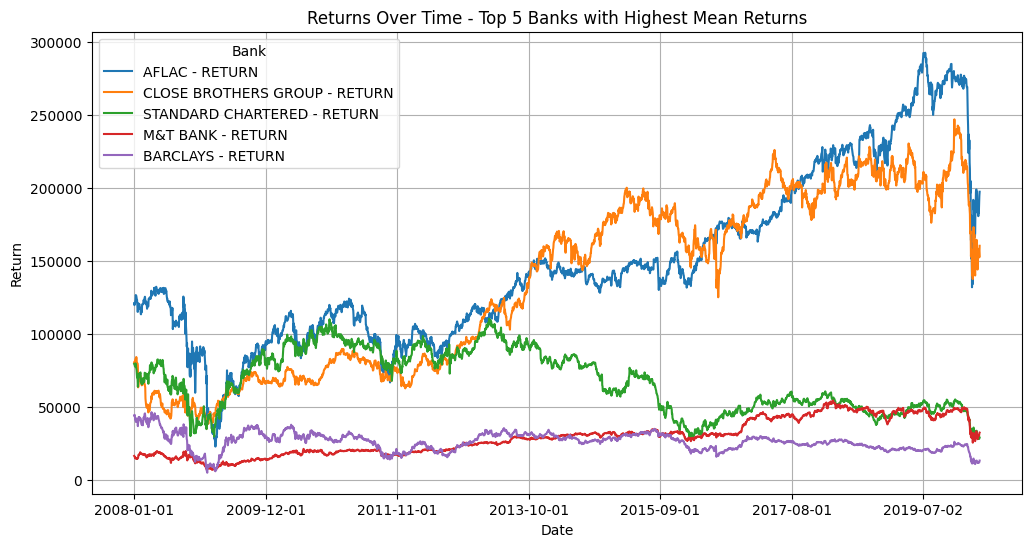

In [85]:
return_cols = [col for col in df.columns if 'RETURN' in col.upper()] + ['Mkt']
returns_df = df[return_cols].copy()

# Calculate mean return for each bank
mean_returns = returns_df.mean().sort_values(ascending=False)

# Get top 5 banks by mean return
top5_banks = mean_returns.head(5).index
print("Top 5 banks with highest mean returns:\n", top5_banks.tolist())

# Plot returns over time
plt.figure(figsize=(12,6))
returns_df[top5_banks].plot(ax=plt.gca())
plt.title("Returns Over Time - Top 5 Banks with Highest Mean Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend(title="Bank")
plt.grid(True)
plt.show()

- AFLAC and CLOSE BROTHERS GROUP dominate in both **growth and average return**, making them the **most profitable over the research period**.
- STANDARD CHARTERED, M&T BANK and BARCLAYS show **more stability but lower mean returns**.
- The **dip near the end of 2019** likely corresponds to market turbulence, possibly related to the initial global market crash triggered by the COVID-19 pandemic.

### Top 5 Banks with the **lowest mean return** over the researched period (with the constraint for the availability of the data for the majority of the researched period): 

Bottom 5 banks with lowest mean returns (and sufficient data):
 ['Mkt', 'LEHMAN BROS.HDG.CAP.TST. III PF.SR.K - RETURN', 'BANCA MONTE DEI PASCHI - RETURN', 'BANCO BPM - RETURN', 'EFG INTERNATIONAL N - RETURN']


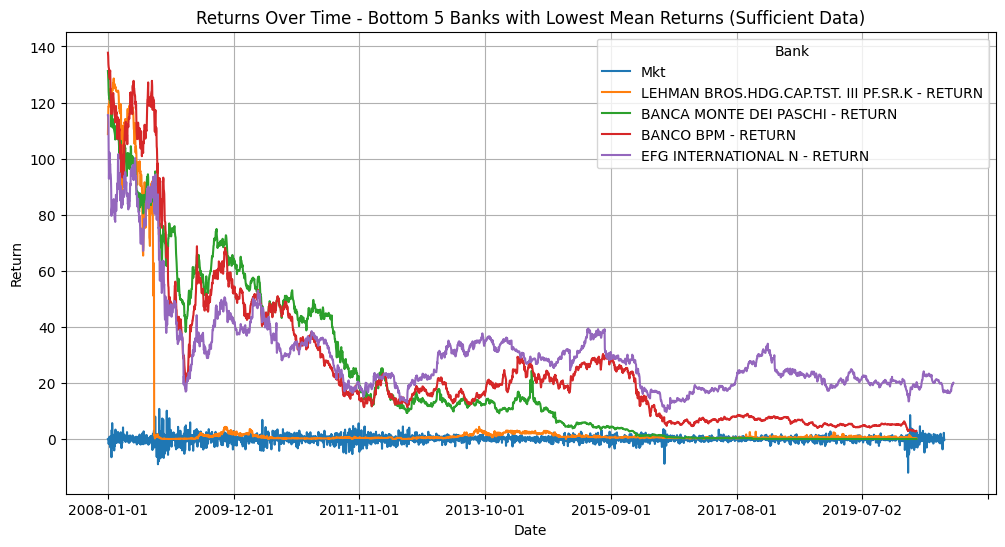

In [86]:
data_coverage = returns_df.notnull().mean()

# Filter out banks with less than, say, 80% data coverage
coverage_threshold = 0.8
valid_banks = data_coverage[data_coverage >= coverage_threshold].index

# Calculate mean returns only for banks with enough data
mean_returns = returns_df[valid_banks].mean().sort_values(ascending=True)

# Select bottom 5 banks by mean return
bottom5_banks = mean_returns.head(5).index
print("Bottom 5 banks with lowest mean returns (and sufficient data):\n", bottom5_banks.tolist())

# Plot their returns over time
plt.figure(figsize=(12,6))
returns_df[bottom5_banks].plot(ax=plt.gca())
plt.title("Returns Over Time - Bottom 5 Banks with Lowest Mean Returns (Sufficient Data)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend(title="Bank")
plt.grid(True)
plt.show()

- Lehman Brothers shows **a sharp collapse in early 2008**, consistent with its **bankruptcy during the global financial crisis** — explaining its extremely low mean return.

- Banca Monte dei Paschi and Banco BPM display **a steady decline from 2008 to 2013/2015**, reflecting prolonged weakness in the Italian banking sector.

- Comdirect Bank shows more stable or slightly upward trends.

Overall, these banks underperformed their peers due to **financial instability, regional economic pressures or structural challenges**.

In [87]:
return_cols = [col for col in df.columns if 'RETURN' in col.upper()]
returns_df = df[return_cols].copy()

# Compute summary statistics
summary_stats = pd.DataFrame({
    'Mean': returns_df.mean(),
    'Std': returns_df.std(),
    'Skewness': returns_df.skew(),
    'Kurtosis': returns_df.kurt()
})

# Sort by mean return (optional)
summary_stats = summary_stats.sort_values(by='Mean', ascending=False)

summary_stats.round(3).head(10)

,Mean,Std,Skewness,Kurtosis
AFLAC - RETURN,147478.588,57645.155,0.671,-0.291
CLOSE BROTHERS GROUP - RETURN,134928.771,59597.329,-0.052,-1.562
STANDARD CHARTERED - RETURN,67667.985,20574.521,0.070,-1.255
M&T BANK - RETURN,29183.285,11997.029,0.296,-1.061
BARCLAYS - RETURN,26267.466,6170.254,-0.079,0.571
ALLIANCE TRUST - RETURN,24160.383,10452.466,0.602,-1.003
FIFTH THIRD BANCORP - RETURN,23130.848,10086.308,0.291,-0.797
SVB FINANCIAL GROUP - RETURN,18107.778,12274.843,0.921,-0.154
WELLS FARGO & CO - RETURN,14658.761,5259.490,-0.078,-1.471
SVENSKA HANDELSBANKEN A - RETURN,13412.426,5160.595,-0.258,-1.430


### Avg Returns vs Volatility

In [88]:
# --- 1. Compute metrics ---
mean_returns = returns_df.mean()                   # average daily return
volatility = returns_df.std()                      # daily volatility

# --- 2. Combine into a summary DataFrame ---
performance_summary = pd.DataFrame({
    'Average Daily Return': mean_returns,
    'Volatility (Std)': volatility
})

# Sort
performance_summary = performance_summary.sort_values(by='Volatility (Std)', ascending=False)

performance_summary.round(4).head(10)

,Average Daily Return,Volatility (Std)
CLOSE BROTHERS GROUP - RETURN,134928.7708,59597.3293
AFLAC - RETURN,147478.5885,57645.1551
STANDARD CHARTERED - RETURN,67667.9851,20574.5211
BANK OF IRELAND GROUP - RETURN,11939.7620,17911.2981
ROYAL BANK OF SCTL.GP. - RETURN,10591.2009,13231.2944
SVB FINANCIAL GROUP - RETURN,18107.7782,12274.8427
M&T BANK - RETURN,29183.2854,11997.0291
AIB GROUP - RETURN,4626.6217,11716.7825
ALLIANCE TRUST - RETURN,24160.3831,10452.4663
FIFTH THIRD BANCORP - RETURN,23130.8480,10086.3075


- Close Brothers Group and AFLAC exhibit the **highest volatility**, suggesting these banks experienced significant fluctuations in their daily returns. Despite high volatility, AFLAC achieved the highest average daily return, indicating strong performance but with elevated risk.

- Standard Chartered shows a **balance between return and volatility**, offering **moderate returns at lower risk** compared to the top two.

- Bank of Ireland Group and Royal Bank of Scotland Group deliver relatively **low returns and moderate volatility**, implying more stable but less profitable performance.

- M&T Bank and Alliance Trust maintain **lower volatility with decent returns**, potentially appealing to more risk-averse investors.

Overall, there’s **a clear risk–return tradeoff**: banks with **higher returns also tend to show higher volatility**.

In [89]:
performance_summary = performance_summary.sort_values(by='Average Daily Return', ascending=True)

# --- Display bottom 10 banks ---
bottom10 = performance_summary.round(4).head(10)
bottom10 = bottom10.sort_values(by='Average Daily Return', ascending=False)
print("Bottom 10 banks by average daily return:\n")
display(bottom10)

Bottom 10 banks by average daily return:



,Average Daily Return,Volatility (Std)
OTP BANKA SLOVENSKO - RETURN,67.1486,66.4426
OTP BANKA SLOVENSKO2 - RETURN,66.1849,69.4446
UNIONE DI BANCHE ITALIAN - RETURN,63.1980,31.1643
BANK OF CYPRUS HOLDING - RETURN,60.7877,22.0245
COMDIRECT BANK - RETURN,49.3775,17.6587
EFG INTERNATIONAL N - RETURN,30.6151,16.7359
BANCO BPM - RETURN,26.8989,27.7052
BANCA MONTE DEI PASCHI - RETURN,22.6478,28.8469
BANKIA - RETURN,12.4491,25.9073
LEHMAN BROS.HDG.CAP.TST. III PF.SR.K - RETURN,6.7450,24.4135


## Correlation Matrix for Top 10 Banks with the highest mean return over the researched period: 

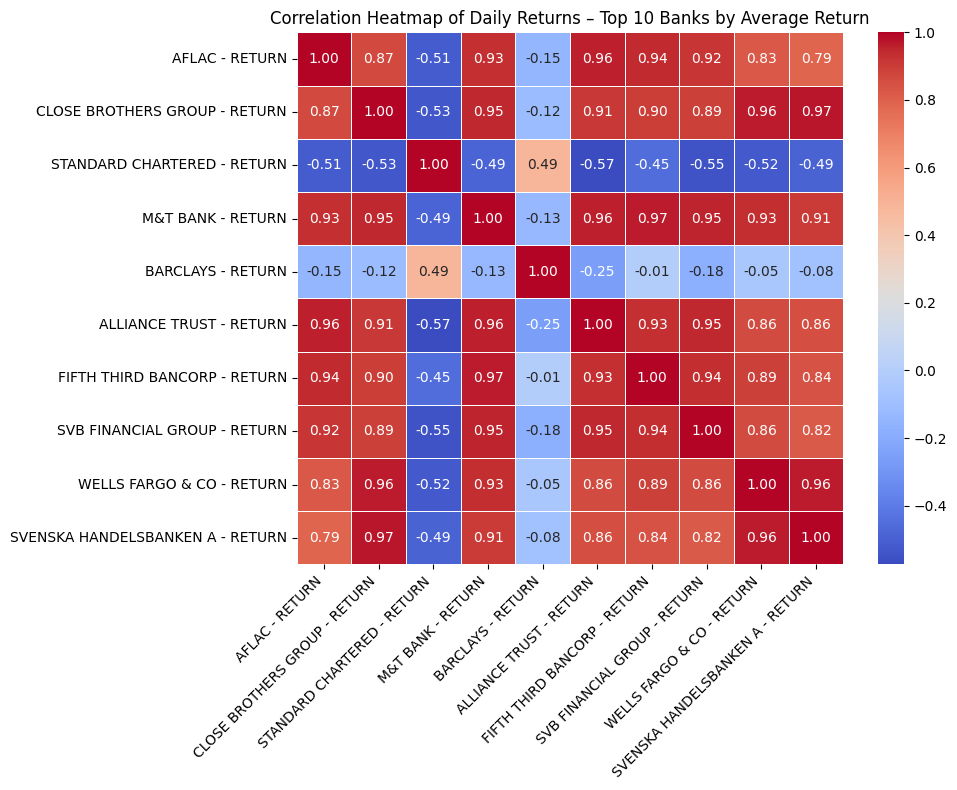

In [90]:
top10_banks = returns_df.mean().sort_values(ascending=False).head(10).index
top10_returns = returns_df[top10_banks]

# --- 3. Compute correlation matrix ---
corr_matrix = top10_returns.corr()

# --- 4. Plot correlation heatmap ---
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Correlation Heatmap of Daily Returns – Top 10 Banks by Average Return")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- The heatmap shows **a strong clustering of positive correlations** among most of the top 10 banks — especially those with high average returns.

- Correlations range mostly between 0.80 and 0.97, meaning that **these banks’ daily returns tend to move in the same direction** on most days. This suggests that the banks are likely influenced by **similar macroeconomic and market factors**.
  
- Close Brothers Group – M&T Bank – Alliance Trust – Fifth Third Bancorp – SVB Financial Group form **a tight cluster**, with correlations typically above 0.90. These institutions likely share **exposure to similar regional or financial market conditions** (UK, US).
  
- Standard Chartered and Barclays stands out with **moderately negative correlations** with most others. They behave counter-cyclically relative to the cluster above — possibly due to their **greater exposure to different geographic focus**.